# NYC Data Job Market Tracker — EDA
**Goal:** Determine what's actually chartable before building the Market Insights page.

Each section ends with a `# DECISION:` comment. Fill those in as you go — they become the build checklist.

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import snowflake.connector
from dotenv import load_dotenv

load_dotenv()

conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database='ANALYTICS_PROD',
    schema='PUBLIC',
)

def run_query(sql):
    cur = conn.cursor()
    cur.execute(sql)
    cols = [d[0].lower() for d in cur.description]
    rows = cur.fetchall()
    return pd.DataFrame(rows, columns=cols)

df = run_query('SELECT * FROM FCT_JOB_POSTINGS')
print(f'Total rows: {len(df)}')
df.head(2)

Total rows: 179


,job_id,source,ingestion_query,job_title,company_name,job_url,date_posted,description,city,state,...,tech_stack_required,tech_stack_preferred,paradigms_required,paradigms_preferred,degree_requirement,years_required_min,years_required_max,confidence_score,enriched_at,ingested_at
0,6vi0NY-dMVCh0ld7AAAAAA==,jsearch,Data Analyst,"[P] Data Scientist, Policy",Anthropic,https://www.linkedin.com/jobs/view/p-data-scie...,2026-06-03,About Anthropic\n\nAnthropic’s mission is to c...,New York,New York,...,"[\n ""python"",\n ""sql""\n]",[],"[\n ""causal inference"",\n ""data analysis""\n]",[],equivalent_ok,6.0,NaN,0.85,2026-06-04 12:11:02.146010+00:00,2026-06-04 12:04:35.529025+00:00
1,aHeua5cfq3q95gzAAAAAAA==,jsearch,Data Analyst,Actimize Business Analyst / Data Analyst,ISite Technologies Inc,https://www.dice.com/job-detail/dbf3a884-755b-...,2026-06-05,Job Role: Actimize Business Analyst\n\nExperie...,Weehawken Township,New Jersey,...,"[\n ""sql""\n]","[\n ""actimize""\n]","[\n ""data quality"",\n ""data analysis""\n]","[\n ""aml"",\n ""suspicious activity monitoring...",none,12.0,12.0,0.90,2026-06-08 13:21:59.990819+00:00,2026-06-08 13:12:11.794894+00:00


## 0. Parse VARIANT array columns
tech_stack_required/preferred and paradigms columns come back as JSON strings from Snowflake.

In [3]:
def parse_variant(val):
    if val is None:
        return []
    if isinstance(val, list):
        return val
    try:
        return json.loads(val)
    except Exception:
        return []

array_cols = ['tech_stack_required', 'tech_stack_preferred', 'paradigms_required', 'paradigms_preferred']
for col in array_cols:
    if col in df.columns:
        df[col] = df[col].apply(parse_variant)

# Normalize text cols
for col in ['role_archetype', 'inferred_seniority', 'work_model', 'employment_type', 'degree_requirement']:
    if col in df.columns:
        df[col] = df[col].str.strip().str.lower()

# Salary as numeric
df['final_salary_min'] = pd.to_numeric(df['final_salary_min'], errors='coerce')
df['final_salary_max'] = pd.to_numeric(df['final_salary_max'], errors='coerce')
df['salary_mid'] = (df['final_salary_min'] + df['final_salary_max']) / 2

# Years as numeric
df['years_required_min'] = pd.to_numeric(df['years_required_min'], errors='coerce')
df['years_required_max'] = pd.to_numeric(df['years_required_max'], errors='coerce')

# Date
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')

print('Dtypes OK')

Dtypes OK


---
## 1. Coverage Checks — Gates Everything Else

In [4]:
total = len(df)

coverage = {
    'salary (either min or max)': df[['final_salary_min','final_salary_max']].notna().any(axis=1).sum(),
    'salary (both min and max)':  df[['final_salary_min','final_salary_max']].notna().all(axis=1).sum(),
    'years_required_min':         df['years_required_min'].notna().sum(),
    'inferred_seniority':         df['inferred_seniority'].notna().sum(),
    'role_archetype':             df['role_archetype'].notna().sum(),
    'tech_stack_required (non-empty)': (df['tech_stack_required'].apply(len) > 0).sum(),
    'is_title_inflated':          df['is_title_inflated'].notna().sum(),
    'work_model':                 df['work_model'].notna().sum(),
}

for k, v in coverage.items():
    print(f'{k:<35} {v:>4} / {total}  ({v/total*100:.0f}%)')

salary (either min or max)           101 / 179  (56%)
salary (both min and max)             99 / 179  (55%)
years_required_min                   130 / 179  (73%)
inferred_seniority                   170 / 179  (95%)
role_archetype                       170 / 179  (95%)
tech_stack_required (non-empty)      152 / 179  (85%)
is_title_inflated                    170 / 179  (95%)
work_model                           179 / 179  (100%)


In [6]:
# Salary coverage broken down by role_archetype — key gate for Investigation 1
salary_df = df[df[['final_salary_min','final_salary_max']].notna().all(axis=1)]
print(f'Rows with full salary data: {len(salary_df)}\n')
print('Salary rows by role_archetype:')
print(salary_df['role_archetype'].value_counts())

# DECISION: if any archetype has < ~15 salary rows, box plot for that group is unreliable
# Note threshold and which archetypes are viable

Rows with full salary data: 99

Salary rows by role_archetype:
role_archetype
data_analyst          69
data_engineer         10
analytics_engineer     9
hybrid                 9
Name: count, dtype: int64


In [7]:
# Salary coverage by inferred_seniority — gate for Investigation 2
print('Salary rows by inferred_seniority:')
print(salary_df['inferred_seniority'].value_counts())

# DECISION: same threshold check

Salary rows by inferred_seniority:
inferred_seniority
mid       64
entry     22
senior    11
Name: count, dtype: int64


---
## 2. Investigation 1 — Tech Stack × Salary Matrix

In [8]:
# role_archetype distribution — what are the actual values?
print('role_archetype value counts:')
print(df['role_archetype'].value_counts())

# DECISION: are the archetype labels consistent / sensible?
# Note any garbage values that need remapping

role_archetype value counts:
role_archetype
data_analyst          115
analytics_engineer     21
data_engineer          20
hybrid                 14
Name: count, dtype: int64


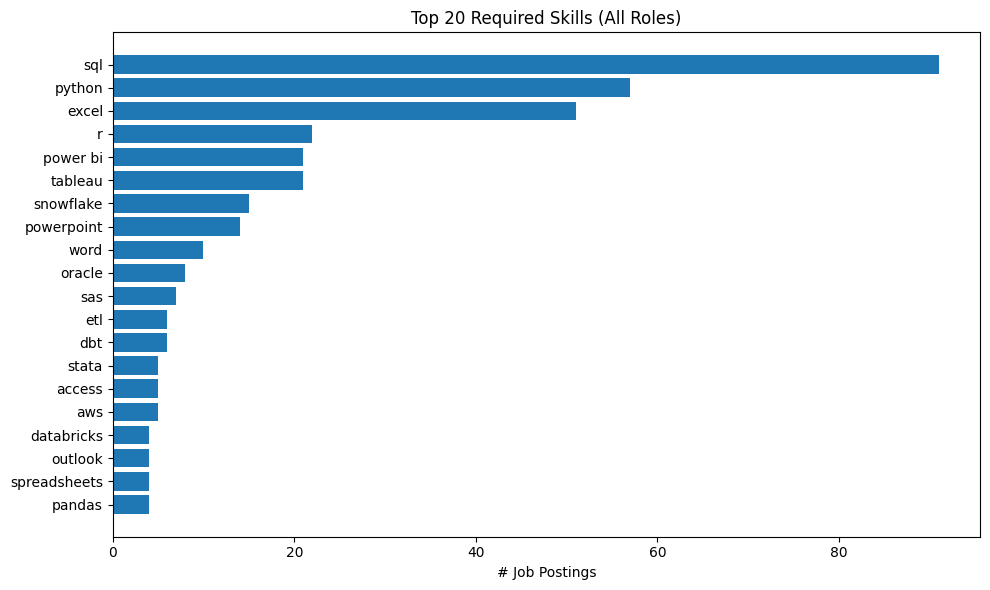

       skill  count
         sql     91
      python     57
       excel     51
           r     22
    power bi     21
     tableau     21
   snowflake     15
  powerpoint     14
        word     10
      oracle      8
         sas      7
         etl      6
         dbt      6
       stata      5
      access      5
         aws      5
  databricks      4
     outlook      4
spreadsheets      4
      pandas      4


In [10]:
# Top 20 required skills overall
all_required = [skill for skills in df['tech_stack_required'] for skill in skills]
skill_counts = Counter(all_required)
top_skills = pd.DataFrame(skill_counts.most_common(20), columns=['skill', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_skills['skill'][::-1], top_skills['count'][::-1])
ax.set_title('Top 20 Required Skills (All Roles)')
ax.set_xlabel('# Job Postings')
plt.tight_layout()
plt.show()

print(top_skills.to_string(index=False))
# DECISION: is there a clean break between 'modern' and 'traditional' skills?
# Does the top-N chart tell a clear enough story on its own?

In [12]:
# Tech stack by role_archetype — does the skill mix actually differ?
archetypes = df['role_archetype'].dropna().unique()

for arch in sorted(archetypes):
    subset = df[df['role_archetype'] == arch]
    skills = [s for skills in subset['tech_stack_required'] for s in skills]
    top = Counter(skills).most_common(10)
    print(f'\n--- {arch} (n={len(subset)}) ---')
    for skill, cnt in top:
        print(f'  {skill}: {cnt}')

# DECISION: are the skill profiles distinct enough per archetype to visualize side-by-side?
# Or does everything just show SQL/Python at the top?


--- analytics_engineer (n=21) ---
  sql: 16
  python: 7
  snowflake: 4
  etl: 3
  r: 3
  sas: 3
  dbt: 2
  redshift: 2
  oracle: 2
  nosql: 2

--- data_analyst (n=115) ---
  sql: 59
  excel: 48
  python: 34
  power bi: 19
  tableau: 18
  r: 17
  powerpoint: 14
  word: 10
  snowflake: 6
  stata: 5

--- data_engineer (n=20) ---
  python: 14
  sql: 12
  snowflake: 4
  databricks: 3
  pyspark: 3
  aws: 3
  oracle: 2
  airflow: 2
  azure data lake storage gen 2: 1
  azure data explorer: 1

--- hybrid (n=14) ---
  sql: 4
  python: 2
  excel: 2
  r: 1
  github: 1
  databricks: 1
  snowflake: 1
  salesforce: 1
  edi: 1
  plm: 1


/var/folders/lc/2rldm7cs08zcbz67h_7qc6vw0000gn/T/ipykernel_4718/1218484720.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=viable_archetypes, vert=True)


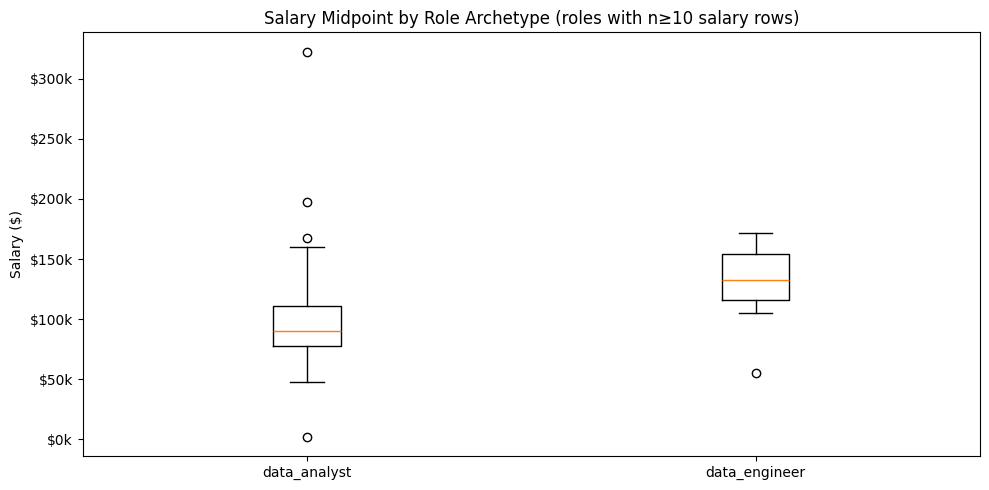

                count      mean       50%      min       max
role_archetype                                              
data_analyst     69.0  100316.0   90000.0   2080.0  322500.0
data_engineer    10.0  129685.0  132500.0  55000.0  172000.0


In [15]:
# Salary distribution by role_archetype (only run if coverage check passed)
fig, ax = plt.subplots(figsize=(10, 5))
viable_archetypes = salary_df['role_archetype'].value_counts()
viable_archetypes = viable_archetypes[viable_archetypes >= 10].index.tolist()

plot_df = salary_df[salary_df['role_archetype'].isin(viable_archetypes)]
groups = [plot_df[plot_df['role_archetype'] == a]['salary_mid'].dropna() for a in viable_archetypes]

ax.boxplot(groups, labels=viable_archetypes, vert=True)
ax.set_title('Salary Midpoint by Role Archetype (roles with n≥10 salary rows)')
ax.set_ylabel('Salary ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

# Summary stats
print(plot_df.groupby('role_archetype')['salary_mid'].describe()[['count','mean','50%','min','max']].round(0))

# DECISION: is there a meaningful salary gap between archetypes?
# If median spread < $15k with high variance, the story is 'murky' not 'clear premium'

In [17]:
# Does tech stack correlate with salary? Check: jobs requiring dbt/Snowflake vs not
modern_skills = ['dbt', 'snowflake', 'airflow', 'spark', 'kafka']
traditional_skills = ['excel', 'tableau', 'power bi', 'sql server', 'access']

def has_any(skills_list, targets):
    return any(s.lower() in targets for s in skills_list)

salary_df = salary_df.copy()
salary_df['has_modern'] = salary_df['tech_stack_required'].apply(lambda x: has_any(x, modern_skills))
salary_df['has_traditional'] = salary_df['tech_stack_required'].apply(lambda x: has_any(x, traditional_skills))

print('Salary: requires modern stack vs not')
print(salary_df.groupby('has_modern')['salary_mid'].describe()[['count','mean','50%']].round(0))

print('\nSalary: requires traditional stack vs not')
print(salary_df.groupby('has_traditional')['salary_mid'].describe()[['count','mean','50%']].round(0))

# DECISION: is the modern stack premium real and large enough to be the headline finding?

Salary: requires modern stack vs not
            count      mean       50%
has_modern                           
False        88.0  114373.0  101250.0
True         11.0  109848.0  105000.0

Salary: requires traditional stack vs not
                 count      mean       50%
has_traditional                           
False             55.0  130188.0  120000.0
True              44.0   93473.0   86625.0


---
## 3. Investigation 2 — Seniority & Title Deconstruction

In [18]:
# inferred_seniority value counts and distribution
print('inferred_seniority value counts:')
print(df['inferred_seniority'].value_counts())

# DECISION: how many distinct levels? are they labeled consistently?
# Note any garbage/inconsistent values

inferred_seniority value counts:
inferred_seniority
mid       104
entry      43
senior     23
Name: count, dtype: int64


In [20]:
# Cross-tab: inferred_seniority vs years_required_min
# This is the core of Investigation 2 — do levels actually stratify by experience req?
seniority_years = df.dropna(subset=['inferred_seniority', 'years_required_min'])
print(f'Rows with both seniority and years_required: {len(seniority_years)}')

print('\nMedian years_required_min by inferred_seniority:')
print(seniority_years.groupby('inferred_seniority')['years_required_min']
      .describe()[['count','mean','50%','min','max']].round(1))

# DECISION: is there meaningful separation between levels?
# If entry-level and mid-level both show median=2 years, the 'gatekeeping' story is confirmed
# If they cleanly ladder up, the story flips — levels ARE real

Rows with both seniority and years_required: 130

Median years_required_min by inferred_seniority:
                    count  mean  50%  min   max
inferred_seniority                             
entry                16.0   0.7  1.0  0.0   2.0
mid                  91.0   2.6  3.0  1.0   9.0
senior               23.0   6.6  5.0  5.0  12.0


In [21]:
# Title inflation analysis
print('is_title_inflated value counts:')
print(df['is_title_inflated'].value_counts(dropna=False))

inflation_rate = df['is_title_inflated'].mean()
print(f'\nOverall inflation rate: {inflation_rate:.1%}')

print('\nInflation rate by inferred_seniority:')
print(df.groupby('inferred_seniority')['is_title_inflated']
      .agg(['sum','count','mean'])
      .rename(columns={'sum':'inflated','mean':'rate'})
      .round(2))

# DECISION: is the inflation rate high enough to be interesting? (>20% is a real finding)
# Does inflation cluster at a specific seniority level? That's the headline

is_title_inflated value counts:
is_title_inflated
False    145
True      25
None       9
Name: count, dtype: int64

Overall inflation rate: 14.7%

Inflation rate by inferred_seniority:
                   inflated  count      rate
inferred_seniority                          
entry                     0     43       0.0
mid                      12    104  0.115385
senior                   13     23  0.565217


In [22]:
# Sample inflation_reasoning for inflated jobs — sanity check on LLM output quality
inflated = df[df['is_title_inflated'] == True][['job_title','inferred_seniority','inflation_reasoning']].head(10)
for _, row in inflated.iterrows():
    print(f'Title: {row["job_title"]} | Seniority: {row["inferred_seniority"]}')
    print(f'Reason: {row["inflation_reasoning"]}')
    print()

# DECISION: are the LLM inflation reasons coherent and trustworthy?
# If they look noisy, caveat this section in the write-up

Title: [P] Data Scientist, Policy | Seniority: mid
Reason: The title 'Data Scientist' suggests a higher level of expertise than the mid-level experience inferred from the qualifications.

Title: Analytics Engineer | Seniority: mid
Reason: The title 'Analytics Engineer' suggests a higher level of expertise than the mid-level experience required.

Title: Analytics Engineer: ELT, BigQuery & Dataform Specialist | Seniority: mid
Reason: The title 'Analytics Engineer' suggests a higher level of expertise than the mid-level experience required.

Title: Azure Databricks Platform Engineer | Seniority: senior
Reason: The title suggests a senior role, but the requirements indicate a senior level of experience.

Title: Business Analyst III AMZ26810.1 | Seniority: mid
Reason: The title suggests a higher level of experience than the minimum requirement of one year.

Title: Business Data Analyst | Seniority: senior
Reason: The title suggests a senior role, but the inferred seniority is based on 5-7 y

In [24]:
# Salary by inferred_seniority — do levels pay differently?
sal_sen = salary_df.dropna(subset=['inferred_seniority'])
print('Salary by inferred_seniority:')
print(sal_sen.groupby('inferred_seniority')['salary_mid']
      .describe()[['count','mean','50%']].round(0))

# DECISION: salary stratification by seniority — real or noisy?
# If mid-level pays only $5k more than entry-level, that's your finding

Salary by inferred_seniority:
                    count      mean       50%
inferred_seniority                           
entry                22.0   81591.0   82924.0
mid                  64.0  120875.0  101250.0
senior               11.0  135195.0  131040.0


---
## 4. Supporting Charts — Work Model, Posting Trends

In [25]:
# Work model breakdown
print('work_model value counts:')
print(df['work_model'].value_counts(dropna=False))

# DECISION: is remote/hybrid/onsite distribution interesting enough to include?
# A simple donut/bar is low-effort — worth including if the split is non-obvious

work_model value counts:
work_model
onsite    130
remote     34
hybrid     15
Name: count, dtype: int64


In [26]:
# Posting trends over time
print(f'Date range: {df["date_posted"].min()} to {df["date_posted"].max()}')
print(f'Distinct dates: {df["date_posted"].nunique()}')
print(f'Rows with date: {df["date_posted"].notna().sum()}')

# Weekly rollup
dated = df.dropna(subset=['date_posted'])
dated = dated.copy()
dated['week'] = dated['date_posted'].dt.to_period('W').dt.start_time
weekly = dated.groupby('week').size().reset_index(name='count')
print('\nWeekly posting counts:')
print(weekly.to_string(index=False))

# DECISION: enough weeks with data to show a trend? Or just noise from 2-3 pipeline runs?
# If < 6 distinct weeks, skip the trend chart — it's misleading

Date range: 2026-05-20 00:00:00 to 2026-06-08 00:00:00
Distinct dates: 13
Rows with date: 179

Weekly posting counts:
      week  count
2026-05-18      1
2026-05-25     30
2026-06-01    137
2026-06-08     11


In [27]:
# Degree requirement distribution
print('degree_requirement value counts:')
print(df['degree_requirement'].value_counts(dropna=False))

# DECISION: is this interesting enough to include, or is it too noisy/expected?

degree_requirement value counts:
degree_requirement
bachelors        77
none             55
equivalent_ok    32
NaN               9
masters           6
Name: count, dtype: int64


---
## 5. Build Checklist
Fill this in after running all cells above.

```
### Coverage Summary
- Total rows: 
- Rows with full salary data: 
- Rows with inferred_seniority + years_required: 
- tech_stack_required fill rate: 

### Investigation 1: Tech Stack × Salary Matrix
- [ ] Top skills chart: viable? (always yes unless fill rate is <30%)
- [ ] Skills by archetype side-by-side: profiles distinct enough? Y/N
- [ ] Salary box plot by archetype: viable archetypes with n≥10 salary rows: ___
- [ ] Modern vs traditional salary premium: delta = $____, finding = real/murky
- Headline finding: 

### Investigation 2: Seniority Deconstruction
- [ ] Seniority × years_required cross-tab: levels stratify cleanly? Y/N
- [ ] Title inflation rate: ____% — headline-worthy (>20%)? Y/N
- [ ] Inflation clusters at seniority level: ____
- [ ] Salary by seniority: real gap or noise? Y/N
- LLM inflation reasoning quality: good/noisy
- Headline finding: 

### Supporting Charts
- [ ] Work model breakdown: include? Y/N
- [ ] Posting trends: enough weeks (≥6) to show trend? Y/N
- [ ] Degree requirement: include? Y/N

### Charts to build for Market Insights page:
1. 
2. 
3. 
4. 
```